In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/kaggle/input/datasets/amineipad/ioittt/train_test_network.csv')

In [3]:
df.head()

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


The first five rows are displayed to understand the structure of the dataset, feature names, and data format.

In [4]:
df.shape

(211043, 44)

The dataset contains 211,000+ records and 44 features.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  object 
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  object 
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  object 
 5   service                 211043 non-null  object 
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  object 
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes        

This helps identify types of features either numerical or categorical, and detect missing values.

In [6]:
df.describe()

,src_port,dst_port,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,211043.000000,211043.000000,211043.000000,2.110430e+05,2.110430e+05,2.110430e+05,211043.000000,2.110430e+05,211043.000000,2.110430e+05,211043.000000,211043.000000,211043.000000,211043.000000,2.110430e+05,211043.000000,211043.000000
mean,38646.519543,3495.153770,7.700887,2.581136e+05,2.588046e+05,3.443234e+04,9.595220,7.760822e+02,3.846861,1.584687e+03,227.630805,3.610909,0.123989,0.065418,1.449295e+02,0.303905,0.763081
std,19307.271048,10191.624778,564.141946,1.709490e+07,1.802563e+07,5.261621e+06,91.778821,2.229703e+04,330.705796,1.901795e+05,2720.713562,23.797747,0.598804,9.243405,3.047244e+04,8.270377,0.425193
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,34608.000000,65.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
50%,44754.000000,80.000000,0.000170,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,8.200000e+01,1.000000,4.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,51133.000000,1253.000000,0.054196,1.300000e+02,8.900000e+01,0.000000e+00,4.000000,4.150000e+02,2.000000,1.340000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,65528.000000,65467.000000,93516.929170,3.890855e+09,3.913853e+09,1.854527e+09,24623.000000,6.522626e+06,121942.000000,8.639552e+07,32769.000000,255.000000,5.000000,2338.000000,1.342438e+07,404.000000,1.000000


This function provides statistical summary of mean, standard deviation, minimum, maximum, and quartiles for numerical features.

In [7]:
df.isnull().sum()

src_ip                    0
src_port                  0
dst_ip                    0
dst_port                  0
proto                     0
service                   0
duration                  0
src_bytes                 0
dst_bytes                 0
conn_state                0
missed_bytes              0
src_pkts                  0
src_ip_bytes              0
dst_pkts                  0
dst_ip_bytes              0
dns_query                 0
dns_qclass                0
dns_qtype                 0
dns_rcode                 0
dns_AA                    0
dns_RD                    0
dns_RA                    0
dns_rejected              0
ssl_version               0
ssl_cipher                0
ssl_resumed               0
ssl_established           0
ssl_subject               0
ssl_issuer                0
http_trans_depth          0
http_method               0
http_uri                  0
http_version              0
http_request_body_len     0
http_response_body_len    0
http_status_code    

This dataset does not contain any missing values.

In [8]:
df['type'].value_counts(normalize=True) * 100

type
normal        23.691854
backdoor       9.476742
ddos           9.476742
dos            9.476742
injection      9.476742
password       9.476742
scanning       9.476742
ransomware     9.476742
xss            9.476742
mitm           0.494212
Name: proportion, dtype: float64

Ten classes that represent typical traffic and various IoT cyberattack categories are included in this dataset. The majority of attack types (backdoor, ddos, dos, injection, password, scanning, ransomware, and xss) each make up about 9.47% of the dataset, whereas normal traffic makes up about 23.7%. However, the MITM attack class is notably underrepresented at roughly 0.49%, suggesting a small class imbalance that could impact the model's capacity to correctly identify this particular attack type.

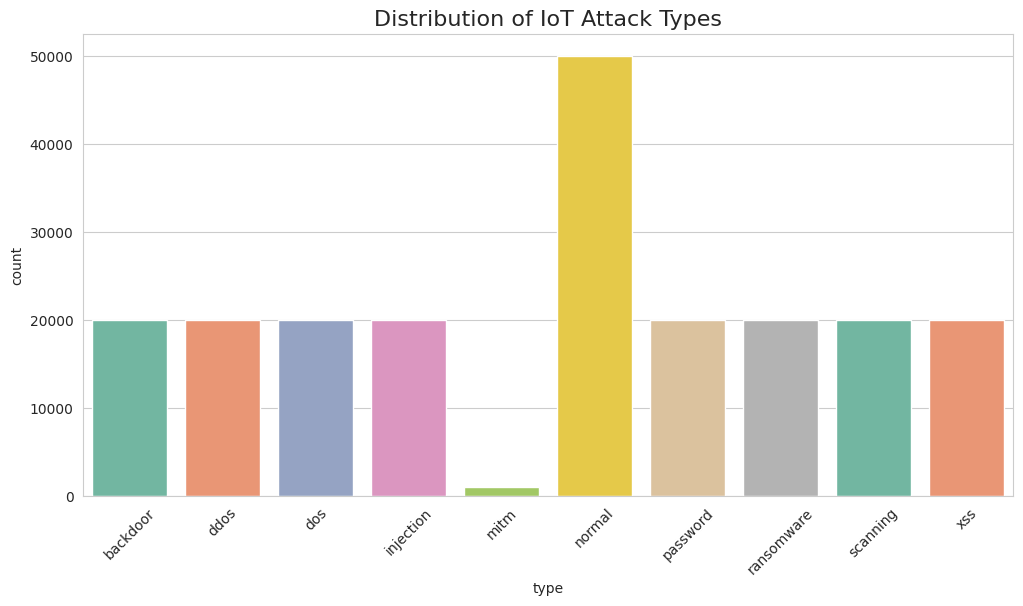

In [9]:
plt.figure(figsize=(12,6))
sns.countplot(x='type', data=df, hue='type', palette="Set2", legend=False)
plt.title("Distribution of IoT Attack Types", fontsize=16)
plt.xticks(rotation=45)
plt.show()

The distribution of IoT attack types is displayed in the bar plot. With the exception of the MITM attack, which is uncommon (~0.5% of data), the majority of classes are fairly evenly represented.


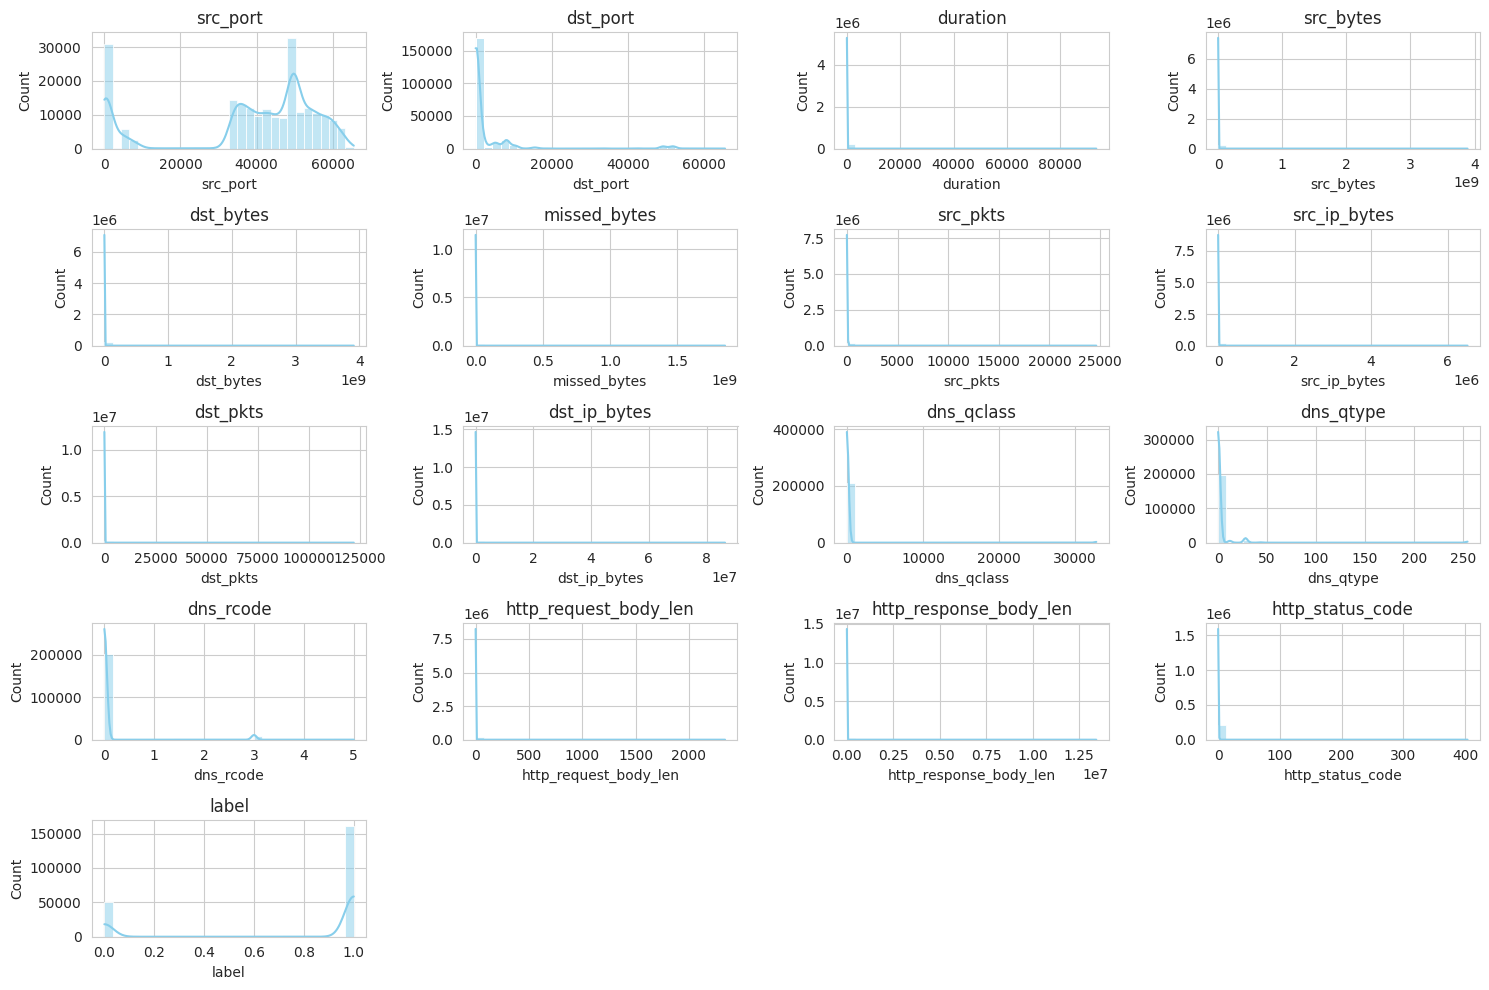

In [10]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols):
    plt.subplot(5,4,i+1)  
    sns.histplot(df[col], bins=30, kde=True, color='skyblue')
    plt.title(col)
    plt.tight_layout()
plt.show()

The distribution of numerical features such as duration, src_bytes, and dst_bytes is displayed in the histograms. Extreme values skew some features, suggesting possible outliers that may require preprocessing attention.

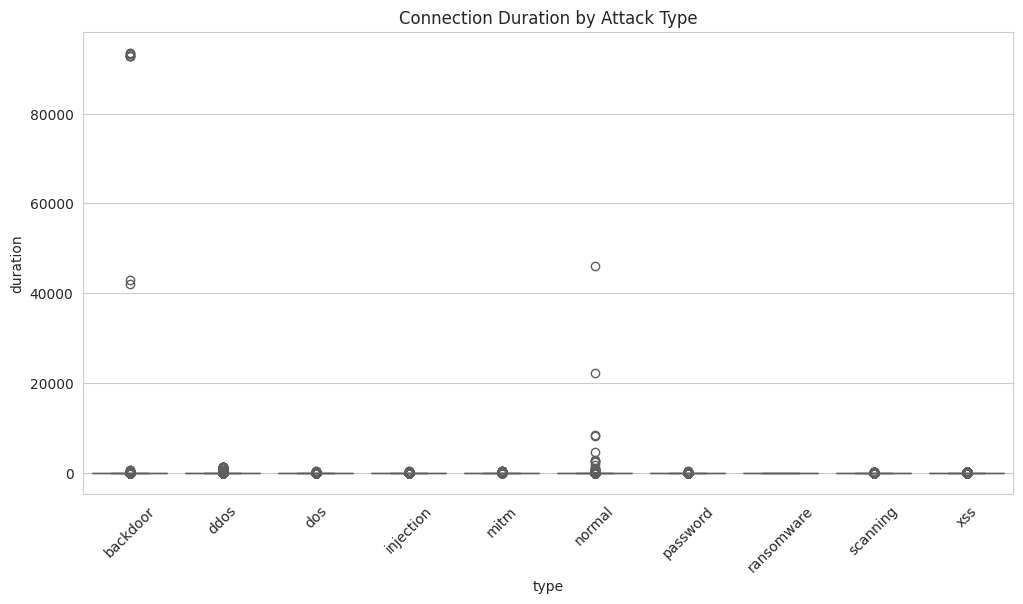

In [11]:
plt.figure(figsize=(12,6))
sns.boxplot(x='type', y='duration', data=df, palette="Set3",hue='type', legend=False)
plt.xticks(rotation=45)
plt.title("Connection Duration by Attack Type")
plt.show()

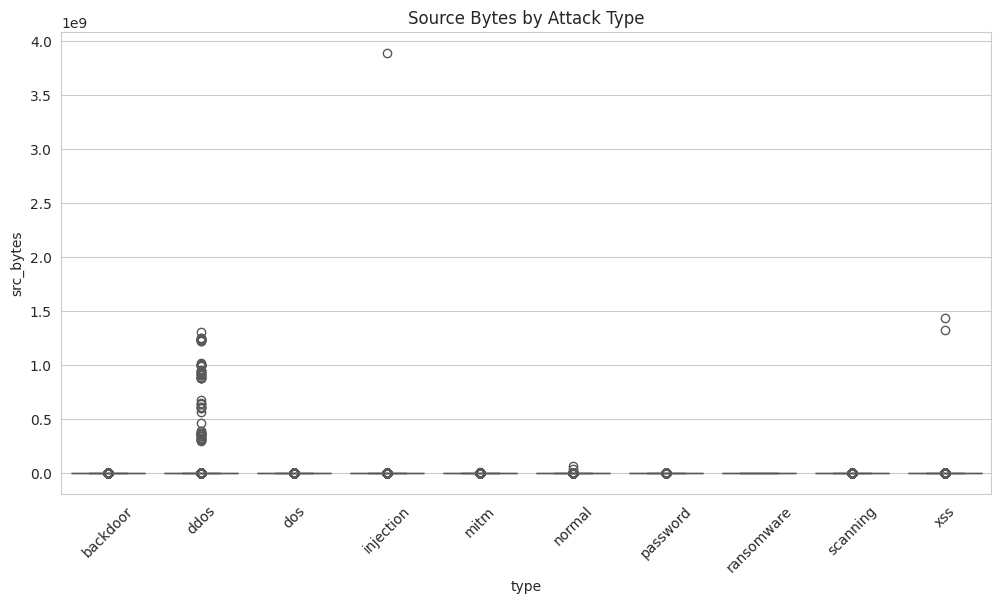

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(x='type', y='src_bytes', data=df, palette="Set2", hue='type', legend=False)
plt.xticks(rotation=45)
plt.title("Source Bytes by Attack Type")
plt.show()

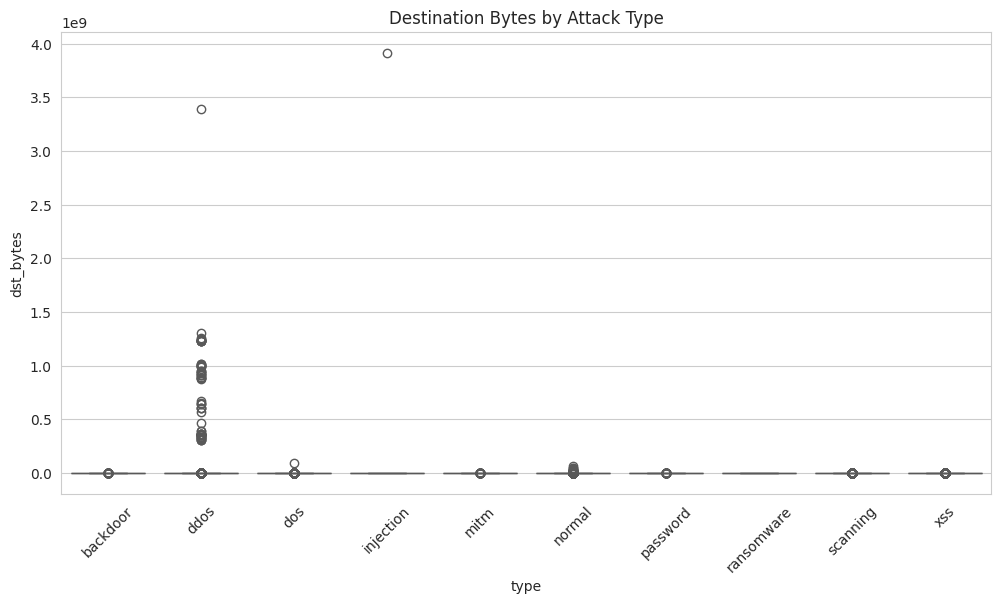

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x='type', y='dst_bytes', data=df, palette="Set2", hue='type', legend=False)
plt.xticks(rotation=45)
plt.title("Destination Bytes by Attack Type")
plt.show()

Boxplots reveal that while some attack types, like xss or mitm, have lower duration and byte values, others, like dos or ddos, have higher values. There are obvious outliers that might require preprocessing in the following stage.

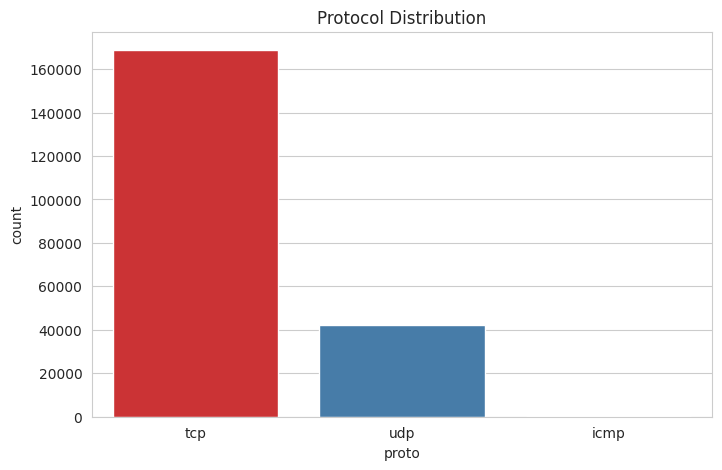

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='proto', data=df, palette="Set1", hue='proto', legend=False)
plt.title("Protocol Distribution")
plt.show()

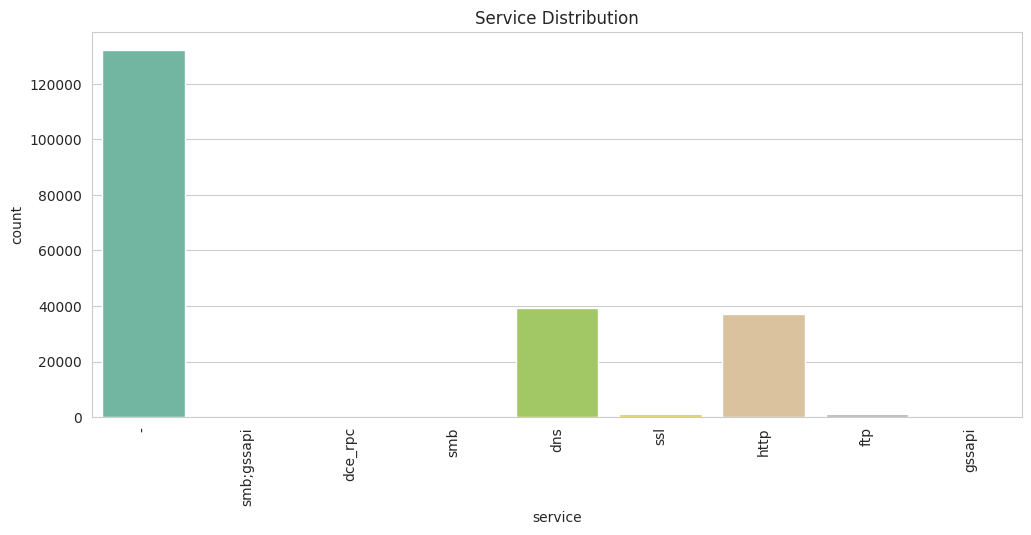

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(x='service', data=df, palette="Set2", hue='service', legend=False)
plt.xticks(rotation=90)
plt.title("Service Distribution")
plt.show()

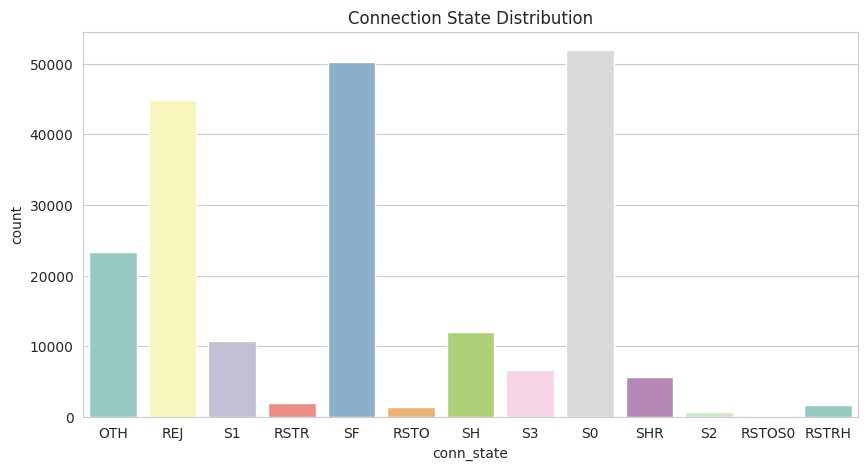

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x='conn_state', data=df, palette="Set3", hue='conn_state', legend=False)
plt.title("Connection State Distribution")
plt.show()

TCP is the most popular protocol, HTTP and DNS are frequently used services, and the majority of connections are in the ESTABLISHED state, according to categorical feature plots. Understanding which network characteristics are linked to various attack types may be made easier with the aid of these insights.

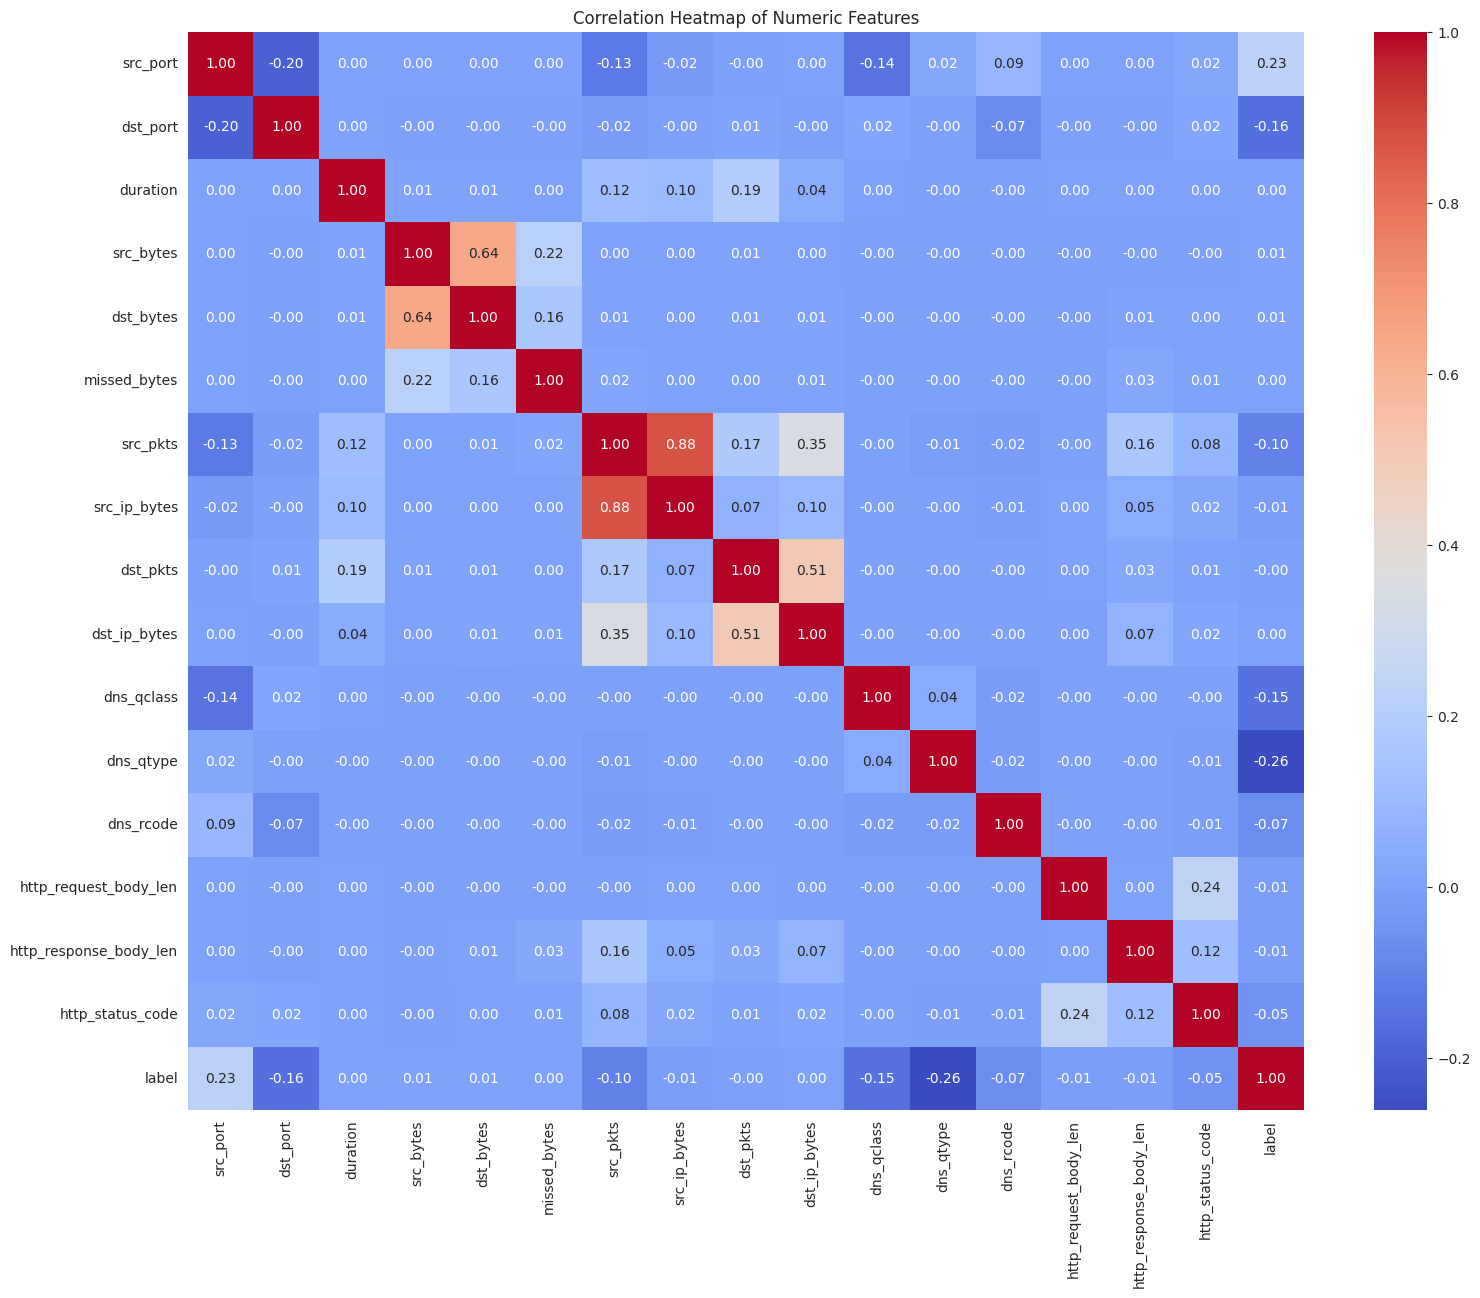

In [18]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(18,14))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Certain numerical features are highly correlated, while others are weakly correlated, according to the correlation heatmap. In the following stage of preprocessing, highly correlated features may be eliminated because they are redundant.

In [19]:
cols_to_drop = ['src_ip', 'dst_ip', 'http_user_agent', 'ssl_issuer','dns_query','http_uri','ssl_subject','weird_addl','weird_notice','http_orig_mime_types','http_resp_mime_types']
df = df.drop(cols_to_drop, axis=1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_port                211043 non-null  int64  
 1   dst_port                211043 non-null  int64  
 2   proto                   211043 non-null  object 
 3   service                 211043 non-null  object 
 4   duration                211043 non-null  float64
 5   src_bytes               211043 non-null  int64  
 6   dst_bytes               211043 non-null  int64  
 7   conn_state              211043 non-null  object 
 8   missed_bytes            211043 non-null  int64  
 9   src_pkts                211043 non-null  int64  
 10  src_ip_bytes            211043 non-null  int64  
 11  dst_pkts                211043 non-null  int64  
 12  dst_ip_bytes            211043 non-null  int64  
 13  dns_qclass              211043 non-null  int64  
 14  dns_qtype           

Dropped IP addresses and text fields because they are unique identifiers or long text strings, which do not help with ML classification at this stage. Some features, such as dns_query, http_uri, and ssl_subject, contain high-cardinality textual information that can create noise and complicate the model. Other features, like weird_addl and weird_notice, mostly include irrelevant metadata. These columns were removed to improve model efficiency and reduce dimensionality.

In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
skew_values = df[numeric_cols].skew().sort_values(ascending=False)

print(skew_values)

dst_ip_bytes              444.670803
http_response_body_len    407.779907
dst_pkts                  291.124803
missed_bytes              252.711993
http_request_body_len     171.711411
src_ip_bytes              165.656573
duration                  155.906273
src_pkts                  134.753842
dst_bytes                 113.944681
src_bytes                 101.369493
http_status_code           29.095322
dns_qclass                 11.877106
dns_qtype                   9.866664
dns_rcode                   4.643585
dst_port                    4.066408
src_port                   -1.063781
label                      -1.237480
dtype: float64


In [21]:
import numpy as np

skewed_cols = ['dst_ip_bytes','http_response_body_len','dst_pkts','missed_bytes',
               'http_request_body_len','src_ip_bytes','duration','src_pkts','dst_bytes','src_bytes']

for col in skewed_cols:
    df[col + '_log'] = np.log1p(df[col])

df[[c+'_log' for c in skewed_cols]].skew()

dst_ip_bytes_log                0.324454
http_response_body_len_log     34.210171
dst_pkts_log                    1.205903
missed_bytes_log               12.691806
http_request_body_len_log     117.300061
src_ip_bytes_log               -0.447448
duration_log                    3.717906
src_pkts_log                    2.288162
dst_bytes_log                   1.219692
src_bytes_log                   0.971131
dtype: float64

Only highly skewed numeric features are log-transformed to lower skewness and compress extreme values. This helps with visualization and gets features ready for ML modeling.

In [22]:
original_skewed_cols = [
    'dst_ip_bytes','http_response_body_len','dst_pkts','missed_bytes',
    'http_request_body_len','src_ip_bytes','duration','src_pkts','dst_bytes','src_bytes'
]

df = df.drop(original_skewed_cols, axis=1)

print(df.shape)
df.info()

(211043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   src_port                    211043 non-null  int64  
 1   dst_port                    211043 non-null  int64  
 2   proto                       211043 non-null  object 
 3   service                     211043 non-null  object 
 4   conn_state                  211043 non-null  object 
 5   dns_qclass                  211043 non-null  int64  
 6   dns_qtype                   211043 non-null  int64  
 7   dns_rcode                   211043 non-null  int64  
 8   dns_AA                      211043 non-null  object 
 9   dns_RD                      211043 non-null  object 
 10  dns_RA                      211043 non-null  object 
 11  dns_rejected                211043 non-null  object 
 12  ssl_version                 211043 non-null  object 
 13  s

Original highly skewed features were removed after applying log transformation to avoid redundancy and reduce feature dimensionality. The log-transformed versions offer a more normalized distribution for modeling.

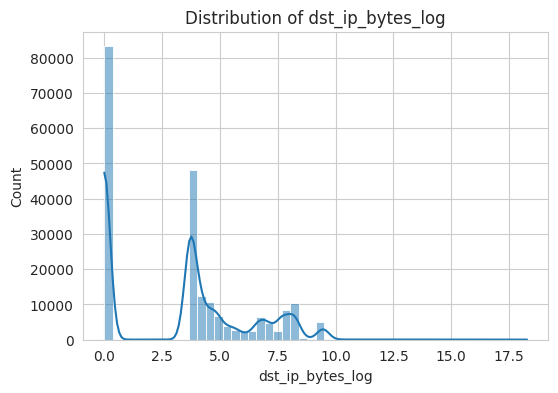

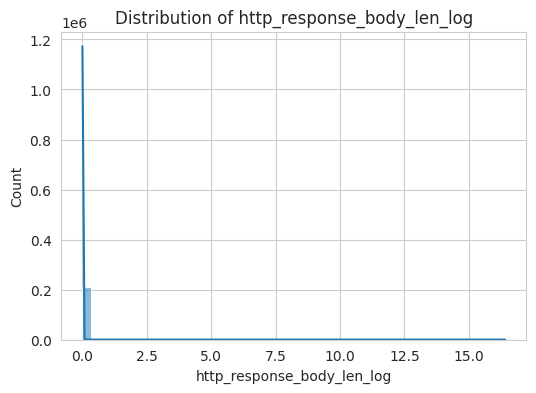

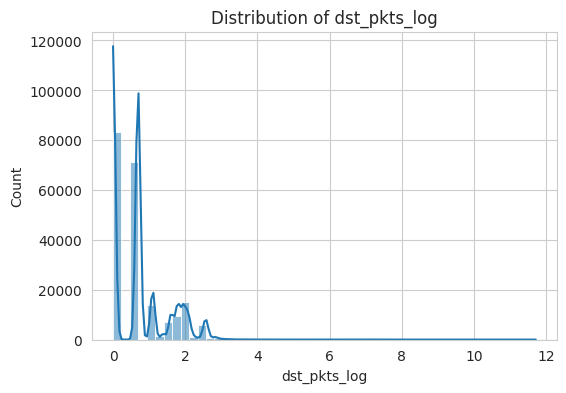

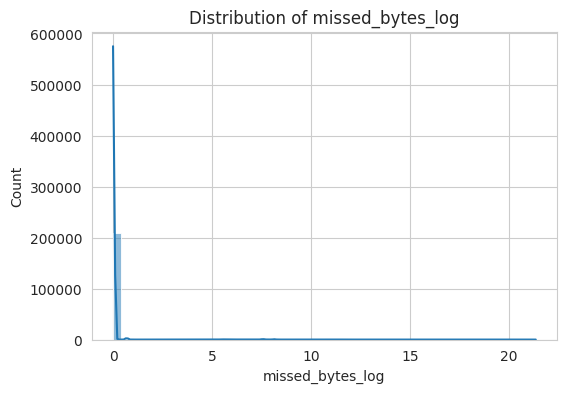

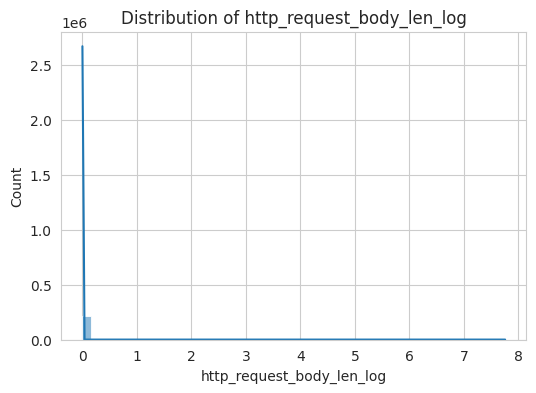

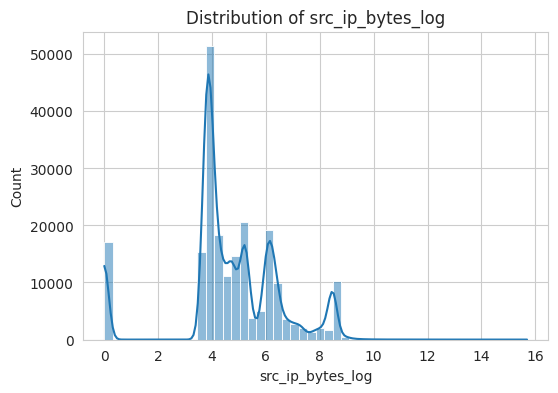

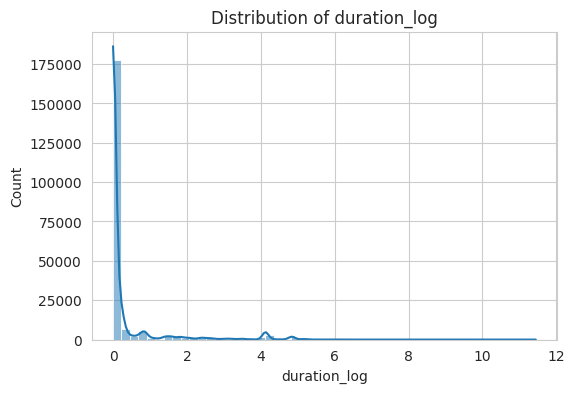

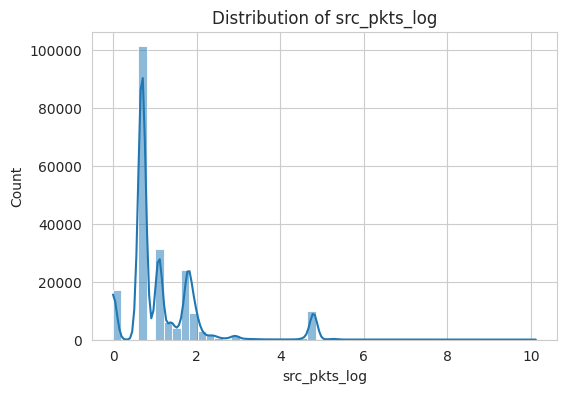

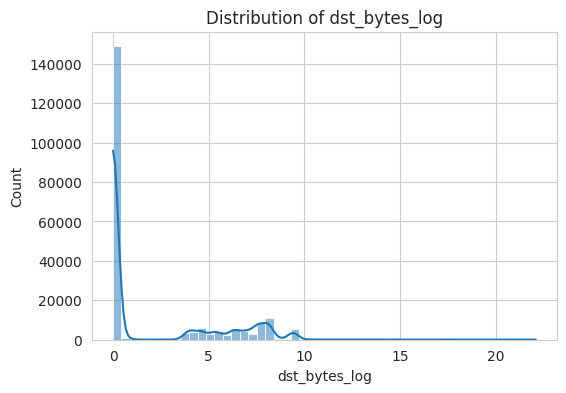

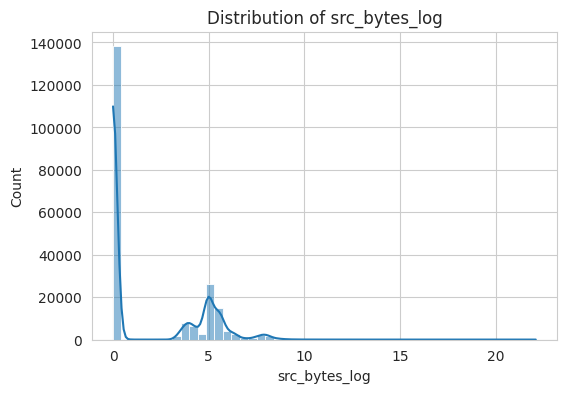

In [23]:
numeric_log_cols = [c for c in df.columns if '_log' in c]

for col in numeric_log_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("Encoding Complete")
df.info()

Encoding Complete
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   src_port                    211043 non-null  int64  
 1   dst_port                    211043 non-null  int64  
 2   proto                       211043 non-null  int64  
 3   service                     211043 non-null  int64  
 4   conn_state                  211043 non-null  int64  
 5   dns_qclass                  211043 non-null  int64  
 6   dns_qtype                   211043 non-null  int64  
 7   dns_rcode                   211043 non-null  int64  
 8   dns_AA                      211043 non-null  int64  
 9   dns_RD                      211043 non-null  int64  
 10  dns_RA                      211043 non-null  int64  
 11  dns_rejected                211043 non-null  int64  
 12  ssl_version                 211043 non-null  int64  
 

The dataset had a lot of features like categorical objects. Machine learning needs numbers to work with. So we used Label Encoding to change these values into numbers. This way the machine learning algorithms can understand the dataset. The Label Encoding method was used to convert the values into a numeric form that the machine learning algorithms can work with.

In [26]:
corr_matrix = df.select_dtypes(include=['int64','float64']).corr()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.90)]

df = df.drop(high_corr_cols, axis=1)
print(high_corr_cols)

[]


We got rid of the features that were really similar to each other. This helps because when features are too similar it can affect how well the machine learning model works. We did this to reduce repetition and make sure the features are not too dependent, on each other. The machine learning model performance is what we care about so we removed the correlated features to make it better.

In [27]:
df.to_csv("preprocessed_iot_dataset.csv", index=False)

The preprocessed dataset is saved so that in future phases we can directly load the cleaned dataset without repeating visualization and preprocessing steps.

In [28]:
from IPython.display import FileLink
FileLink('preprocessed_iot_dataset.csv')

/kaggle/working/preprocessed_iot_dataset.csv